<a href="https://colab.research.google.com/github/luckytas96-ux/Proyecto_DS_ParteI_Scalise/blob/main/Proyecto_DS_ParteI_Scalise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Final - Visualizaciones en Python

#Primera entrega



# **Archivo: Proyecto_DS_ParteI_Scalise.ipynb**

---
---

## **Abstract**

El presente proyecto tiene como propósito analizar el fenómeno del suicidio en la República Argentina a partir del dataset **“Hechos y víctimas de suicidios en la República Argentina. Total nacional”**, disponible en el portal de datos abiertos del gobierno ([datos.gob.ar](https://datos.gob.ar/)). Este conjunto de datos contiene **25 920 registros**, que abarcan el período comprendido entre **2017 y 2023**, con **18 variables** que describen las características del hecho, el contexto en el que ocurrió y los atributos de la persona involucrada. Cada registro representa un evento individual, proporcionando información valiosa para el estudio de **patrones espaciales, temporales y demográficos** del suicidio en el país.

El **objetivo del análisis** es realizar una **exploración sistemática de los datos** mediante técnicas de análisis **univariado, bivariado y multivariado**, con el fin de identificar **tendencias significativas, comportamientos recurrentes y relaciones** entre las distintas variables. A través del análisis de datos se busca obtener una comprensión más profunda del fenómeno, evaluando su **evolución temporal**, las **diferencias por género y grupo etario**, la **distribución geográfica de los casos** y las **modalidades más frecuentes**.

El estudio de este tipo de información resulta de **gran relevancia social**, ya que el suicidio constituye una **problemática de salud pública** que requiere políticas de prevención basadas en evidencia. La posibilidad de examinar **datos abiertos** de manera estructurada y reproducible permite **detectar patrones de riesgo**, **identificar grupos etarios y regiones con mayor incidencia**, y generar **insumos cuantitativos** para el diseño de **intervenciones preventivas**.  
En definitiva, este trabajo busca demostrar cómo el uso de la **analítica de datos** puede contribuir al desarrollo de **estrategias más efectivas y focalizadas** en la prevención del suicidio en Argentina.

---
---

## **Preguntas / Hipótesis de interes**

1.¿Cómo ha sido la evolución de los suicidios a lo largo de los años?

2.¿Qué provincias tienen los mayores casos?

3.¿Cuales son los rangos de edad con mayor cantidad de suicidios?

4.¿Existen diferencias entre hombres y mujeres?

5.¿Hay meses con mayor cantidad de suicidios?

6.¿Cuál es la modalidad más utilizada para llevar a cabo el suicidio?

---
---

## **Objetivo del proyecto**

El objetivo principal de este proyecto es analizar y comprender el comportamiento del suicidio en la República Argentina entre los años 2017 y 2023, aplicando técnicas de análisis exploratorio y visualización de datos para obtener una visión integral del fenómeno del suicidio en Argentina, aportando información que pueda ser útil para la formulación de políticas públicas y programas de prevención basados en evidencia



---
---

## **Visualizacion de datos**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Cargar Datos
url = "https://raw.githubusercontent.com/luckytas96-ux/Proyecto_DS_ParteI_Scalise/refs/heads/main/dataset_data_science_1.csv"
df = pd.read_csv(url)
df.head()


,id_hecho,tipo_persona_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,anio,mes,fecha_hecho,hora_hecho,tipo_lugar,tipo_lugar_ampliado,modalidad,motivo_origen_registro,suicida_sexo,suicida_tr_edad,suicida_18_años_o_mas
0,8529,Suicida idRegistro 20712,La Pampa,42002,Norte (General Pico),105030,General Pico,2017,1,8/1/2017,13:25:00,Vía pública,Vía pública,Ahorcamiento,Intervención policial,Masculino,20-24,Si
1,8530,Suicida idRegistro 20713,La Pampa,42003,Sur (General Acha),70030,Guatraché,2017,1,9/1/2017,01:00:00,Domicilio particular,Domicilio particular,Arma de fuego,Intervención policial,Masculino,55-59,Si
2,8569,Suicida idRegistro 20752,Santa Cruz,78021,Güer Aike,60,28 de Noviembre,2017,1,1/1/2017,19:00:00,Vía pública,Vía pública,Ahorcamiento,Denuncia particular,Masculino,15-19,No
3,8705,Suicida idRegistro 20894,Neuquén,58035,Confluencia,70,Neuquén,2017,1,31/1/2017,17:30:00,Otro Lugar ( Especificar ),Hotel/Motel/Hospedaje temporario,Arma de fuego,Intervención policial,Masculino,20-24,Si
4,8706,Suicida idRegistro 20895,Neuquén,58035,Confluencia,100,Plottier,2017,1,31/1/2017,22:40:00,Domicilio particular,Domicilio particular,Ahorcamiento,Intervención policial,Masculino,20-24,Si


---
---

## **Missing Values**

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
tipo_lugar_ampliado,2


Se observa que hay valores faltantes en la columna de tipo_lugar_ampliado. Se reemplazaran por "sin determinar"

In [ ]:
df['tipo_lugar_ampliado'] = df['tipo_lugar_ampliado'].fillna('sin determinar')

Si volvemos a ejecutar el código, veremos que ya no hay valores nulos

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


---
---

## **Análisis univariado**

Evolución de la cantidad de suicidios a lo largo de los años

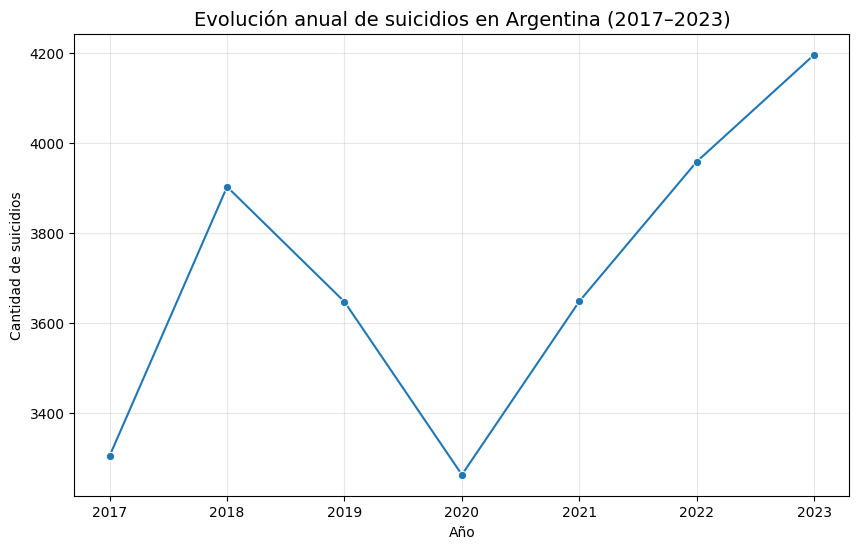

In [ ]:
suicidios_por_anio = df.groupby('anio').size().reset_index(name='cantidad_casos')
plt.figure(figsize=(10, 6))
sns.lineplot(data=suicidios_por_anio, x='anio', y='cantidad_casos', marker='o')
plt.title('Evolución anual de suicidios en Argentina (2017–2023)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de suicidios')
plt.grid(True, alpha=0.3)
plt.show()

---
---

## **Analisis bivariado**

Cantidad de suicidios por mes en cada provincia

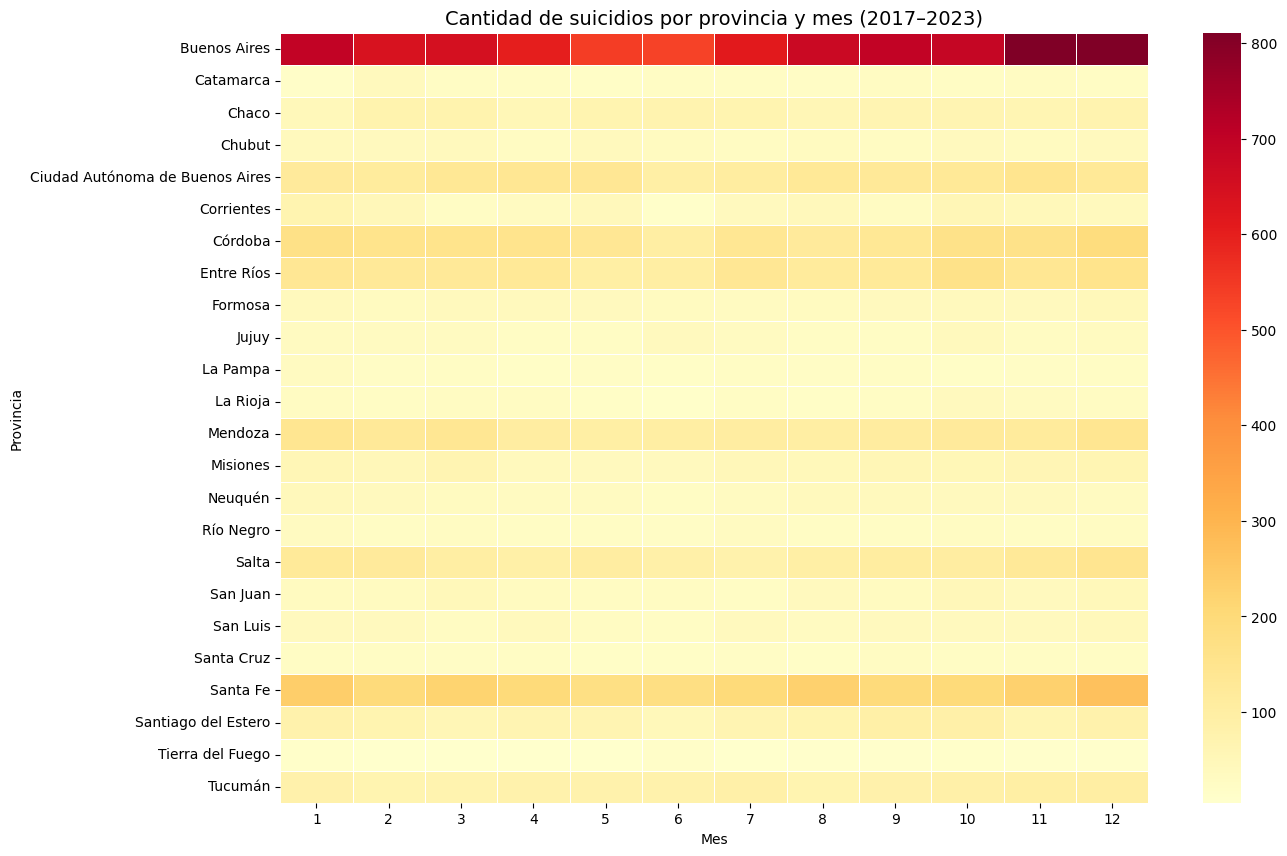

In [ ]:
pivot_prov_mes = df.groupby(['provincia_nombre', 'mes']).size().reset_index(name='cantidad_casos')
tabla_calor = pivot_prov_mes.pivot(index='provincia_nombre', columns='mes', values='cantidad_casos').fillna(0)
plt.figure(figsize=(14, 10))
sns.heatmap(tabla_calor, cmap='YlOrRd', linewidths=0.5)
plt.title('Cantidad de suicidios por provincia y mes (2017–2023)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Provincia')
plt.show()

---
---

## **Análisis multivariado**

Rango de edad vs Sexo vs Modalidad

📋 Rangos de edad incluidos en el gráfico:
• 20-24
• 25-29
• 15-19
• 30-34
• 35-39


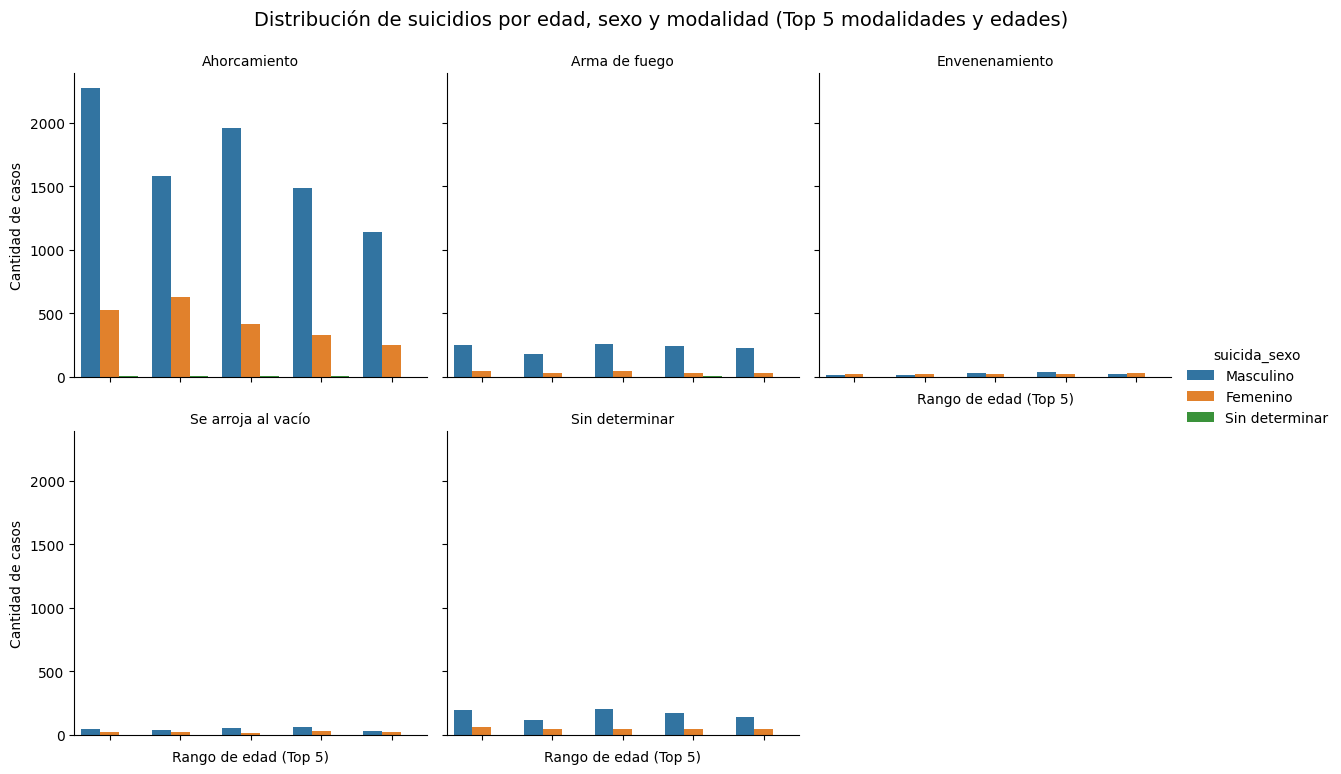

In [ ]:
top5_modalidades = df['modalidad'].value_counts().nlargest(5).index
top5_edades = df['suicida_tr_edad'].value_counts().nlargest(5).index
df_top = df[(df['modalidad'].isin(top5_modalidades)) & (df['suicida_tr_edad'].isin(top5_edades))]
g = sns.catplot(
    data=df_top,
    x='suicida_tr_edad',
    hue='suicida_sexo',
    col='modalidad',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1
)
g.set_titles("{col_name}")
g.set_axis_labels("Rango de edad (Top 5)", "Cantidad de casos")
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de suicidios por edad, sexo y modalidad (Top 5 modalidades y edades)", fontsize=14)
print("📋 Rangos de edad incluidos en el gráfico:")
for edad in top5_edades:
    print(f"• {edad}")
plt.show()

---
---

## **Conclusiones preliminares**

1.La cantidad de suicidios ha ido en aumento desde 2021 en adelante

2.La provincia de Buenos Aires tiene por mucha diferencia la mayor cantidad de suicidios.

3.Entre los 15 y 39 años se producen la mayor cantidad de suicidios.

4.Se observa una diferencia notoria entre hombres y mujeres, siendo los primeros los más afectados.

5.No se observan cambios relevantes entre los distintos meses.

6.La mayor cantidad de suicidios son llevados a cabo mediante el ahorcamiento.

---
---

## **Acciones que podría realizar para mi dataset**

In [ ]:
# Eliminar columnas con información poco útil para el análisis

df.drop(columns=['motivo_origen_registro'], inplace=True)



In [ ]:
df.head()

,id_hecho,tipo_persona_id,provincia_nombre,departamento_id,departamento_nombre,localidad_id,localidad_nombre,anio,mes,fecha_hecho,hora_hecho,tipo_lugar,tipo_lugar_ampliado,modalidad,suicida_sexo,suicida_tr_edad,suicida_18_años_o_mas
0,8529,Suicida idRegistro 20712,La Pampa,42002,Norte (General Pico),105030,General Pico,2017,1,8/1/2017,13:25:00,Vía pública,Vía pública,Ahorcamiento,Masculino,20-24,Si
1,8530,Suicida idRegistro 20713,La Pampa,42003,Sur (General Acha),70030,Guatraché,2017,1,9/1/2017,01:00:00,Domicilio particular,Domicilio particular,Arma de fuego,Masculino,55-59,Si
2,8569,Suicida idRegistro 20752,Santa Cruz,78021,Güer Aike,60,28 de Noviembre,2017,1,1/1/2017,19:00:00,Vía pública,Vía pública,Ahorcamiento,Masculino,15-19,No
3,8705,Suicida idRegistro 20894,Neuquén,58035,Confluencia,70,Neuquén,2017,1,31/1/2017,17:30:00,Otro Lugar ( Especificar ),Hotel/Motel/Hospedaje temporario,Arma de fuego,Masculino,20-24,Si
4,8706,Suicida idRegistro 20895,Neuquén,58035,Confluencia,100,Plottier,2017,1,31/1/2017,22:40:00,Domicilio particular,Domicilio particular,Ahorcamiento,Masculino,20-24,Si


---
---

## **Aplicar algun metodo de outliers detection**

In [ ]:
original_size = df.shape[0]
print(f"Tamaño original del dataset: {original_size}")

Tamaño original del dataset: 25920


**Con IQR (Interquartile Range)**

🔹 Provincias outliers:


,provincia_nombre,casos,es_outlier
0,Buenos Aires,7949,True


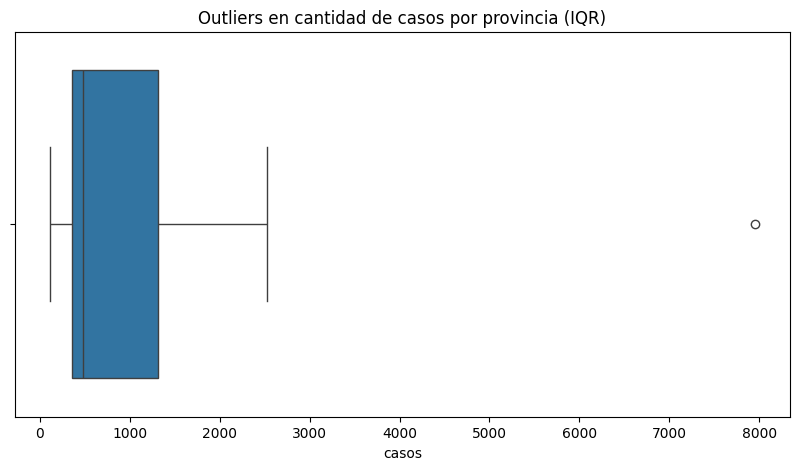

In [ ]:
conteos_prov = df.groupby('provincia_nombre').size().reset_index(name='casos')
Q1 = conteos_prov['casos'].quantile(0.25)
Q3 = conteos_prov['casos'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
conteos_prov['es_outlier'] = (conteos_prov['casos'] < low) | (conteos_prov['casos'] > high)
print("🔹 Provincias outliers:")
display(conteos_prov[conteos_prov['es_outlier']].sort_values('casos', ascending=False))
plt.figure(figsize=(10,5))
sns.boxplot(data=conteos_prov, x='casos')
plt.title("Outliers en cantidad de casos por provincia (IQR)")
plt.show()

---
---

## **Modelo de machine learning: modalidad del suicidio**

En esta sección se construirá un modelo de clasificación para predecir la modalidad del suicidio a partir de variables demográficas y contextuales.

Se aplican los siguientes pasos:

1. Importación de librerías, codificación de variables y selección de características (**feature selection**).
2. Entrenamiento y comparación de dos algoritmos de clasificación:
   - Regresión logística multiclase.
   - Random Forest.
3. Evaluación mediante métricas de clasificación y matriz de confusión.
4. Generación de conclusiones.

## 1.Feature selection

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Target que será usado: modalidad del suicidio
target = "modalidad"

# Features que se usarán
features = [
    "anio",
    "mes",
    "provincia_nombre",
    "tipo_lugar",
    "suicida_sexo",
    "suicida_tr_edad"
]

# Subconjunto de datos para el modelo
df_model = df[features + [target]].dropna()

print("Filas originales:", len(df))
print("Filas usadas para el modelo:", len(df_model))
print("\nClases de 'modalidad':")
print(df_model[target].value_counts())

Filas originales: 25920
Filas usadas para el modelo: 25920

Clases de 'modalidad':
modalidad
Ahorcamiento                        17242
Arma de fuego                        3911
Sin determinar                       2176
Se arroja al vacío                    877
Envenenamiento                        682
Arma blanca /  elemento cortante      316
Se arroja a las vías de FF.CC.        308
Sumersión en piscina / mar / río      188
Se incinera                           153
Otra modalidad                         67
Name: count, dtype: int64


## 2.Entrenamiento de algoritmos

In [ ]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = features

# One-Hot Encoding para variables categóricas
prepro = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Feature selection con chi-cuadrado
selector = SelectKBest(score_func=chi2, k=25)

# 1) Regresión Logística multiclase
model_lr = Pipeline(steps=[
    ("prepro", prepro),
    ("select", selector),
    ("clf", LogisticRegression(max_iter=500, multi_class="multinomial"))
])

# 2) Random Forest
model_rf = Pipeline(steps=[
    ("prepro", prepro),
    ("select", selector),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['anio', 'mes',
                                                   'provincia_nombre',
                                                   'tipo_lugar', 'suicida_sexo',
                                                   'suicida_tr_edad'])])),
                ('select',
                 SelectKBest(k=25,
                             score_func=<function chi2 at 0x7f563614a7a0>)),
                ('clf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## 3.Evaluación

## *Metricas*

In [ ]:
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

print("===================================")
print("      Regresión Logística")
print("===================================")
print(classification_report(y_test, y_pred_lr))

print("===================================")
print("          Random Forest")
print("===================================")
print(classification_report(y_test, y_pred_rf))

      Regresión Logística
                                  precision    recall  f1-score   support

                    Ahorcamiento       0.74      0.97      0.84      3448
Arma blanca /  elemento cortante       0.00      0.00      0.00        63
                   Arma de fuego       0.47      0.08      0.13       782
                  Envenenamiento       0.00      0.00      0.00       136
                  Otra modalidad       0.00      0.00      0.00        14
  Se arroja a las vías de FF.CC.       0.87      0.89      0.88        62
              Se arroja al vacío       0.42      0.29      0.34       175
                     Se incinera       0.00      0.00      0.00        31
                  Sin determinar       0.85      0.73      0.78       435
Sumersión en piscina / mar / río       0.25      0.03      0.05        38

                        accuracy                           0.74      5184
                       macro avg       0.36      0.30      0.30      5184
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## *Matriz de Confusión*

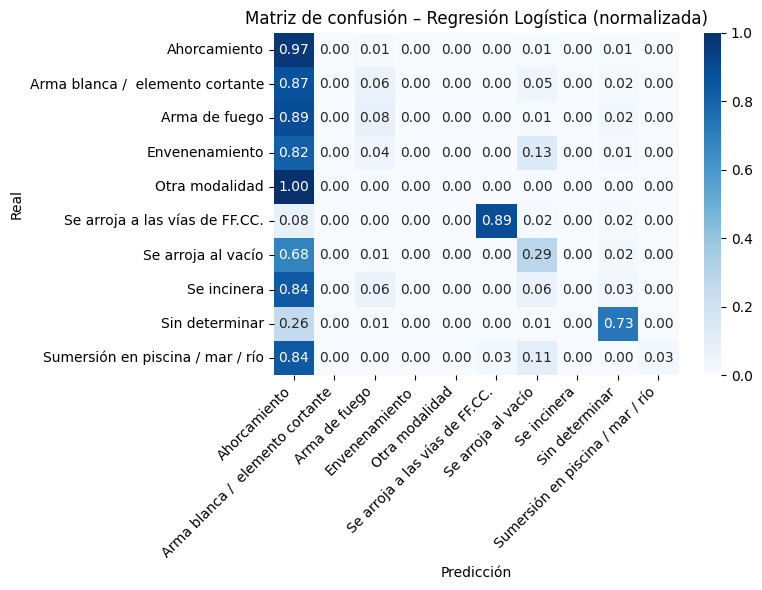

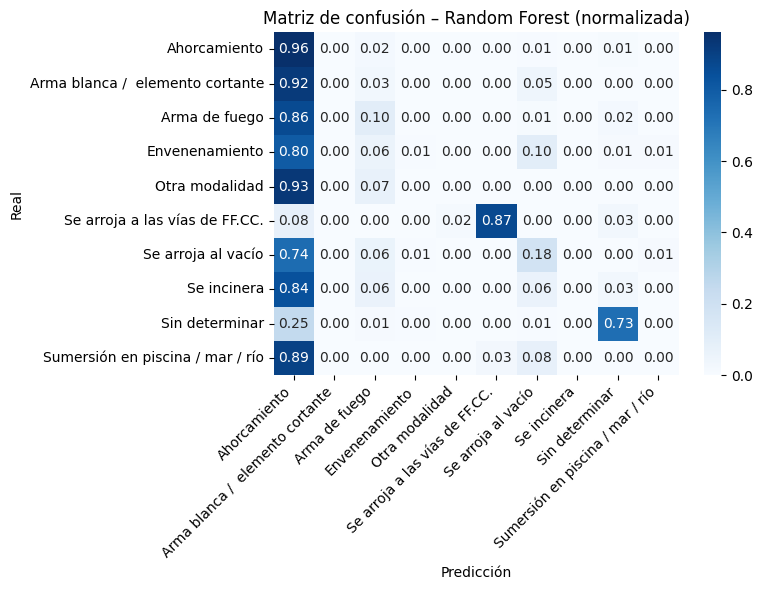

In [ ]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true),
                cmap="Blues")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, y_pred_lr, "Matriz de confusión – Regresión Logística (normalizada)")
plot_confusion(y_test, y_pred_rf, "Matriz de confusión – Random Forest (normalizada)")

## 4. Conclusiones acerca de los modelos predictivos

Se entrenaron dos modelos de clasificación: Regresión Logística multiclase y Random Forest, con el objetivo de predecir la modalidad del suicidio a partir de variables demográficas y contextuales. Para esto se aplicó codificación One-Hot Encoding y feature selection mediante SelectKBest con chi-cuadrado.

Los resultados muestran que ambos presentan un desempeño limitado para la mayoría de las clases, con excepción de la categoría de Ahorcamiento, que concentra aproximadamente el 70% de los casos del dataset. Esta fuerte desproporción genera un desequilibrio severo en las clases, lo que provoca que los modelos tiendan a predecir mayormente esa modalidad. Esto explica por qué la precisión y el recall de Ahorcamiento son muy altos (0.96–0.97), mientras que la mayoría de las modalidades restantes presentan valores cercanos a 0 en una o varias métricas.

Ambos modelos tienen un bajo rendimientos para las modalidades menos frecuentes. Esto indica que los algoritmos de clasificación tienen dificultades para identificar patrones claros en las modalidades minoritarias, probablemente debido a la falta de ejemplos suficientes para estas categorías.

Las matrices de confusión refuerzan esta observación: la mayoría de los errores corresponden a predicciones erróneas que terminan clasificándose como Ahorcamiento, lo cual es consistente con el desequilibrio de los datos. El modelo, al no encontrar patrones robustos para distinguir entre clases poco representadas, opta por la modalidad más frecuente.

En síntesis, el análisis muestra que:

1. Los modelos no pueden predecir adecuadamente la mayoría de las modalidades, debido al desbalance extremo del dataset.

2. Ambos modelos tienen desempeño similar, pero no alcanzan un nivel óptimo.

3. El dataset no proporciona señales suficientemente diferenciadas para discriminar entre modalidades minoritarias, incluso con técnicas de selección de características.

4. A pesar de su baja capacidad predictiva, el modelo permite identificar la fuerte concentración del método de ahorcamiento, lo cual constituye un hallazgo relevante desde la perspectiva epidemiológica.